In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [25]:
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
import shap

In [26]:
#load
df_weather = pd.read_csv("/content/state_weather_data_1997_2020.csv")
df_crop = pd.read_csv("/content/crop_yield.csv")

df_weather.columns = df_weather.columns.str.lower()
df_crop.columns = df_crop.columns.str.lower()

In [27]:
#  FILTER
df_crop = df_crop[df_crop['crop'].isin(['Wheat', 'Rice'])]
df_crop = df_crop[(df_crop['year'] >= 2000) & (df_crop['year'] <= 2018)]
df_weather = df_weather[(df_weather['year'] >= 2000) & (df_weather['year'] <= 2018)]

In [28]:
# MERGE
df = pd.merge(df_crop, df_weather, on=['state', 'year'], how='inner')

In [57]:
df.head()

,year,temperature,rainfall,humidity,yield,agri_input,temp_squared,humidity_squared,rainfall_squared,humidity_temp,temp_rainfall,log_rainfall,rainfall_per_temp,year_trend,year_squared,agri_weather,state_encoded,crop_Wheat
0,2000,27.74,1070.25,70.73,2.700000,2.956515e+08,769.5076,5002.7329,1.145435e+06,1962.0502,29688.735,6.976581,37.239040,0,0,8.201374e+09,2.298462,False
1,2000,27.74,1070.25,70.73,2.939091,1.219600e+08,769.5076,5002.7329,1.145435e+06,1962.0502,29688.735,6.976581,37.239040,0,0,3.383170e+09,2.298462,False
2,2000,27.74,1070.25,70.73,0.581818,1.403710e+06,769.5076,5002.7329,1.145435e+06,1962.0502,29688.735,6.976581,37.239040,0,0,3.893892e+07,2.298462,True
3,2000,22.37,1958.50,75.29,1.197826,5.311923e+07,500.4169,5668.5841,3.835722e+06,1684.2373,43811.645,7.580445,83.804022,0,0,1.188277e+09,1.580597,False
4,2000,22.37,1958.50,75.29,1.825217,3.240857e+07,500.4169,5668.5841,3.835722e+06,1684.2373,43811.645,7.580445,83.804022,0,0,7.249797e+08,1.580597,False


In [29]:
# SELECT + RENAME
df = df[['crop', 'state', 'year',
         'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent',
         'fertilizer', 'pesticide', 'yield']]

df.rename(columns={
    'avg_temp_c': 'temperature',
    'total_rainfall_mm': 'rainfall',
    'avg_humidity_percent': 'humidity'
}, inplace=True)

In [30]:
# HANDLE MISSING
df.fillna(df.median(numeric_only=True), inplace=True)

In [58]:
df.head()

,year,temperature,rainfall,humidity,yield,agri_input,temp_squared,humidity_squared,rainfall_squared,humidity_temp,temp_rainfall,log_rainfall,rainfall_per_temp,year_trend,year_squared,agri_weather,state_encoded,crop_Wheat
0,2000,27.74,1070.25,70.73,2.700000,2.956515e+08,769.5076,5002.7329,1.145435e+06,1962.0502,29688.735,6.976581,37.239040,0,0,8.201374e+09,2.298462,False
1,2000,27.74,1070.25,70.73,2.939091,1.219600e+08,769.5076,5002.7329,1.145435e+06,1962.0502,29688.735,6.976581,37.239040,0,0,3.383170e+09,2.298462,False
2,2000,27.74,1070.25,70.73,0.581818,1.403710e+06,769.5076,5002.7329,1.145435e+06,1962.0502,29688.735,6.976581,37.239040,0,0,3.893892e+07,2.298462,True
3,2000,22.37,1958.50,75.29,1.197826,5.311923e+07,500.4169,5668.5841,3.835722e+06,1684.2373,43811.645,7.580445,83.804022,0,0,1.188277e+09,1.580597,False
4,2000,22.37,1958.50,75.29,1.825217,3.240857e+07,500.4169,5668.5841,3.835722e+06,1684.2373,43811.645,7.580445,83.804022,0,0,7.249797e+08,1.580597,False


In [31]:
#  EXPLORATORY DATA ANALYSIS
df.shape

(1480, 9)

In [32]:
df.dtypes

,0
crop,object
state,object
year,int64
temperature,float64
rainfall,float64
humidity,float64
fertilizer,float64
pesticide,float64
yield,float64


In [33]:
df.isnull().sum()

,0
crop,0
state,0
year,0
temperature,0
rainfall,0
humidity,0
fertilizer,0
pesticide,0
yield,0


In [34]:
df.describe()

,year,temperature,rainfall,humidity,fertilizer,pesticide,yield
count,1480.000000,1480.000000,1480.000000,1480.000000,1.480000e+03,1.480000e+03,1480.000000
mean,2009.415541,23.595824,1430.287959,65.687973,1.230369e+08,2.354135e+05,2.154300
std,5.473610,4.614151,694.735333,12.106568,2.261538e+08,4.480204e+05,0.886810
min,2000.000000,6.980000,303.740000,36.540000,1.508000e+02,3.100000e-01,0.000000
25%,2005.000000,22.520000,920.102500,54.620000,2.850305e+06,5.467875e+03,1.494728
50%,2010.000000,25.230000,1290.070000,69.830000,2.569640e+07,4.605964e+04,2.073423
75%,2014.000000,26.630000,1799.120000,75.270000,1.459795e+08,2.718031e+05,2.682708
max,2018.000000,28.630000,5244.360000,86.060000,1.630162e+09,3.706118e+06,5.342500


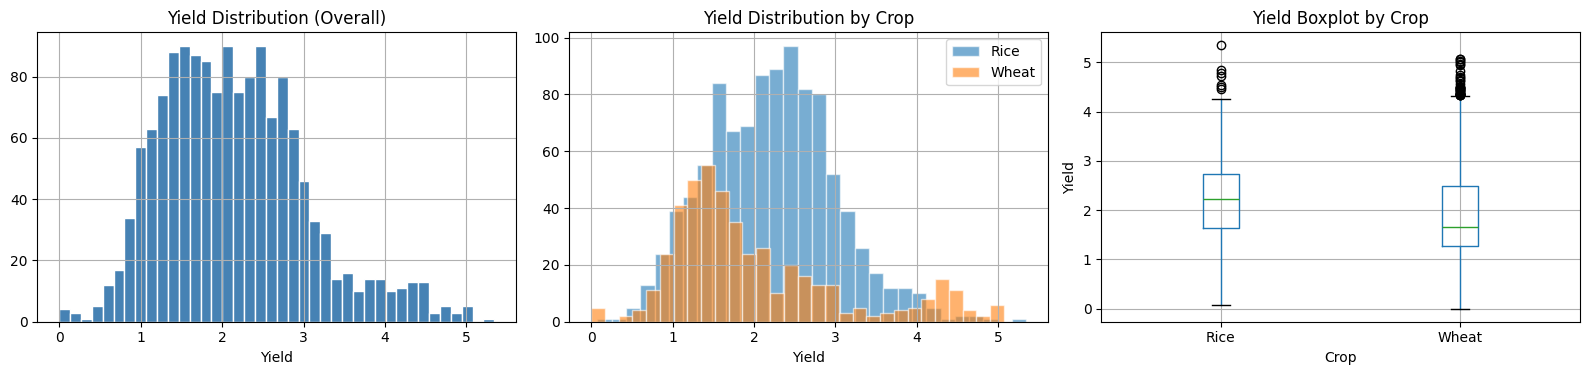

In [35]:
#Target distribution (overall + by crop)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['yield'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Yield Distribution (Overall)")
axes[0].set_xlabel("Yield")

for crop, grp in df.groupby('crop'):
    grp['yield'].hist(bins=30, ax=axes[1], alpha=0.6, label=crop, edgecolor='white')
axes[1].set_title("Yield Distribution by Crop")
axes[1].set_xlabel("Yield")
axes[1].legend()

df.boxplot(column='yield', by='crop', ax=axes[2])
axes[2].set_title("Yield Boxplot by Crop")
axes[2].set_xlabel("Crop")
axes[2].set_ylabel("Yield")
plt.suptitle("")
plt.tight_layout()
plt.show()

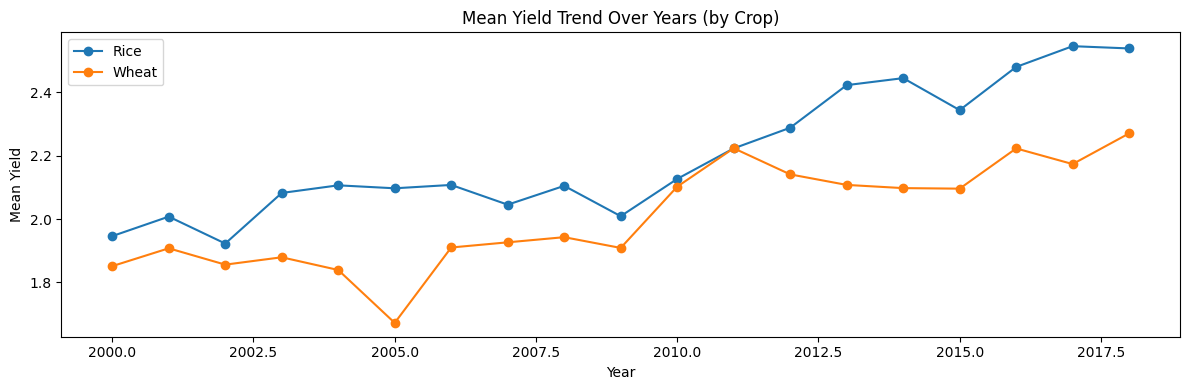

In [36]:
#Temporal trend: yield over years
fig, ax = plt.subplots(figsize=(12, 4))
for crop, grp in df.groupby('crop'):
    yearly = grp.groupby('year')['yield'].mean()
    ax.plot(yearly.index, yearly.values, marker='o', label=crop)
ax.set_title("Mean Yield Trend Over Years (by Crop)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Yield")
ax.legend()
plt.tight_layout()
plt.show()

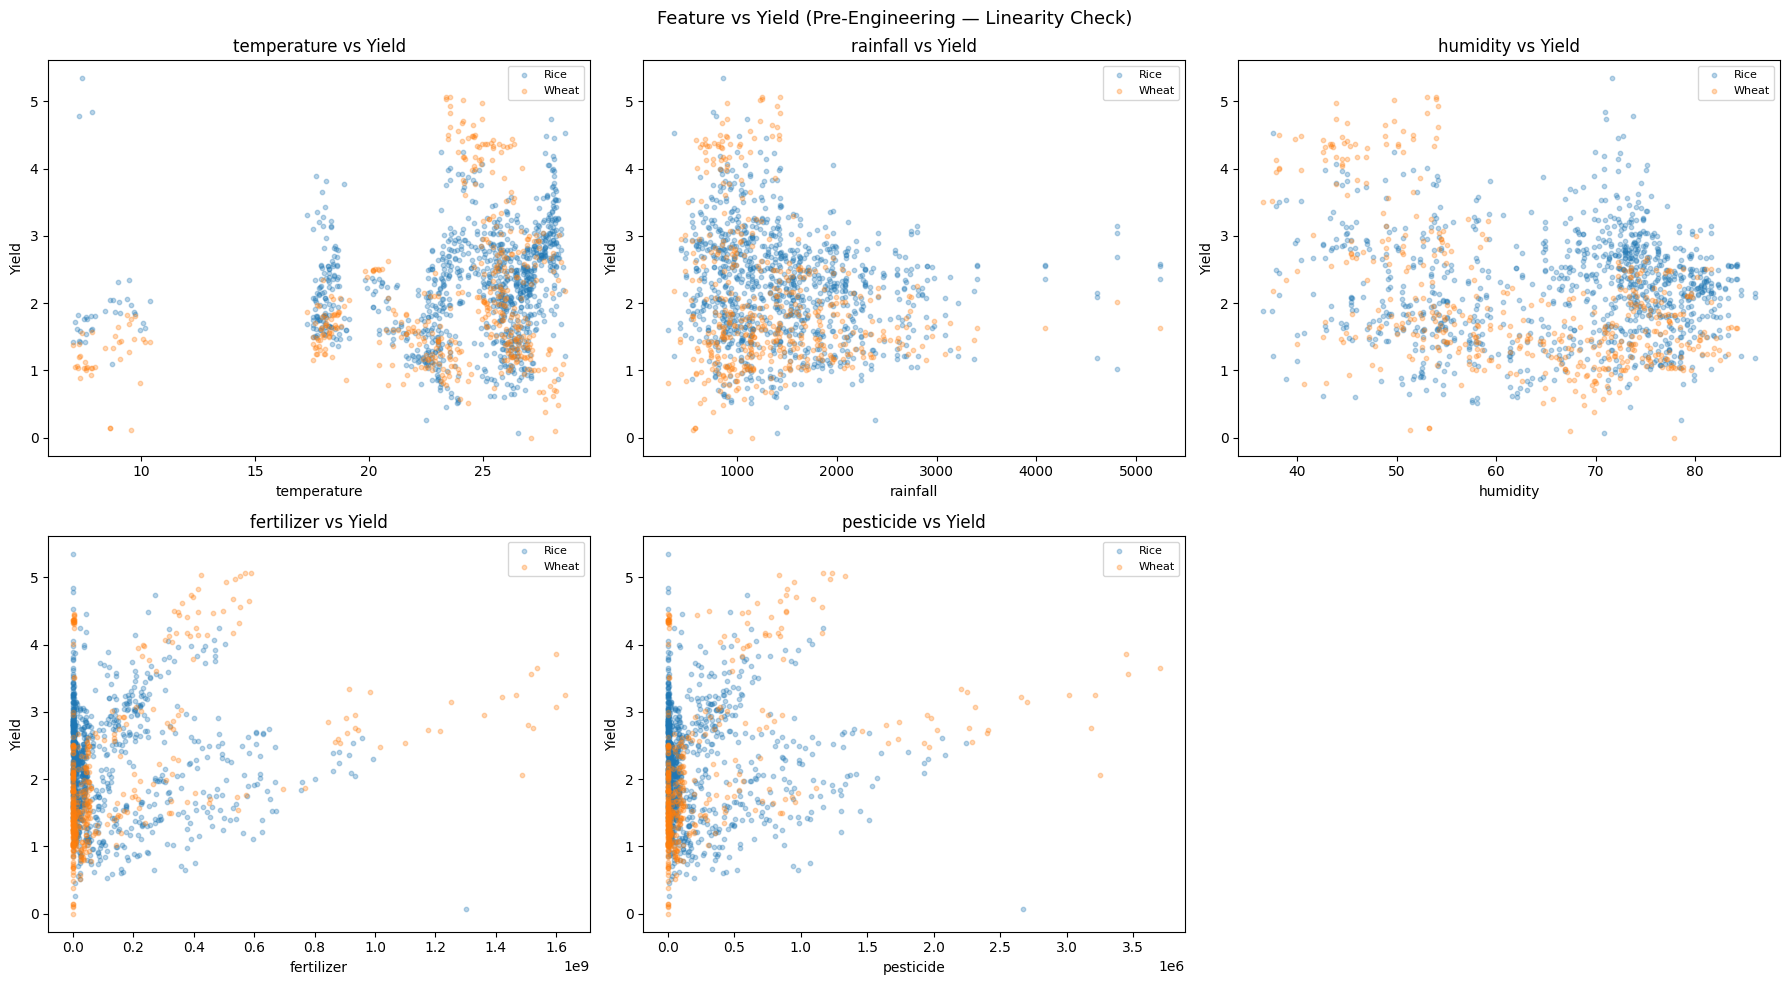

In [37]:
#Feature vs yield scatter plots (key non-linearity check)
features_to_check = ['temperature', 'rainfall', 'humidity', 'fertilizer', 'pesticide']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(features_to_check):
    for crop, grp in df.groupby('crop'):
        axes[i].scatter(grp[feat], grp['yield'], alpha=0.3, s=10, label=crop)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Yield")
    axes[i].set_title(f"{feat} vs Yield")
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle("Feature vs Yield (Pre-Engineering — Linearity Check)", fontsize=13)
plt.tight_layout()
plt.show()

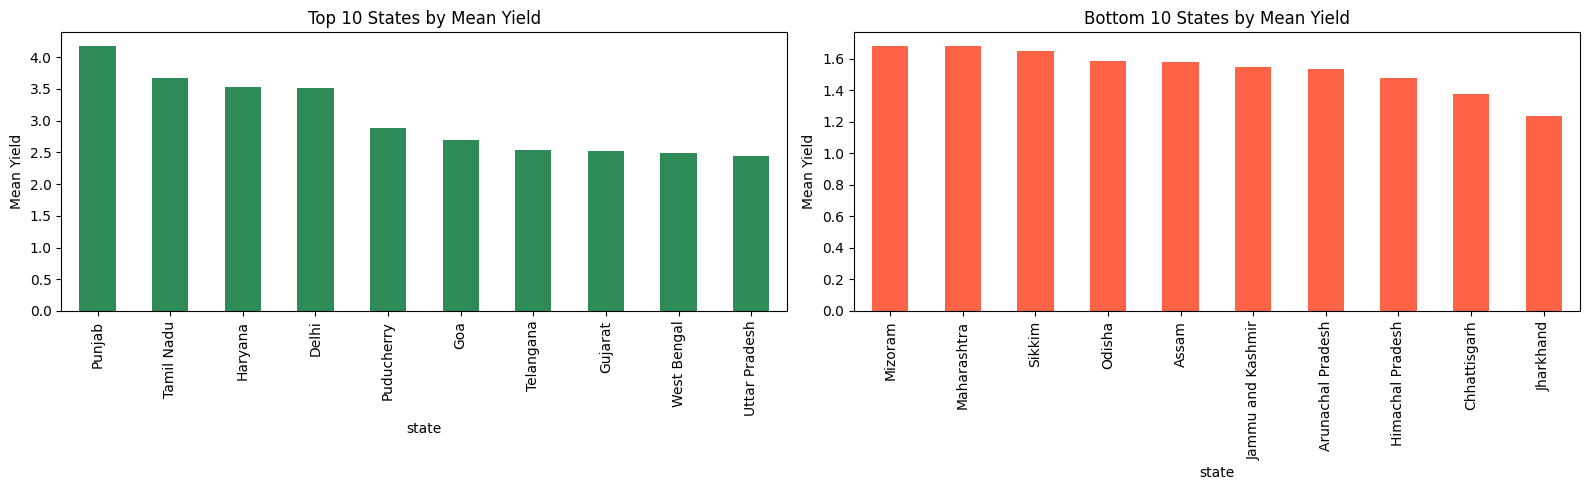

In [38]:
# State-level yield distribution (top/bottom states)
state_yield = df.groupby('state')['yield'].mean().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

state_yield.head(10).plot(kind='bar', ax=axes[0], color='seagreen')
axes[0].set_title("Top 10 States by Mean Yield")
axes[0].set_ylabel("Mean Yield")

state_yield.tail(10).plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title("Bottom 10 States by Mean Yield")
axes[1].set_ylabel("Mean Yield")

plt.tight_layout()
plt.show()

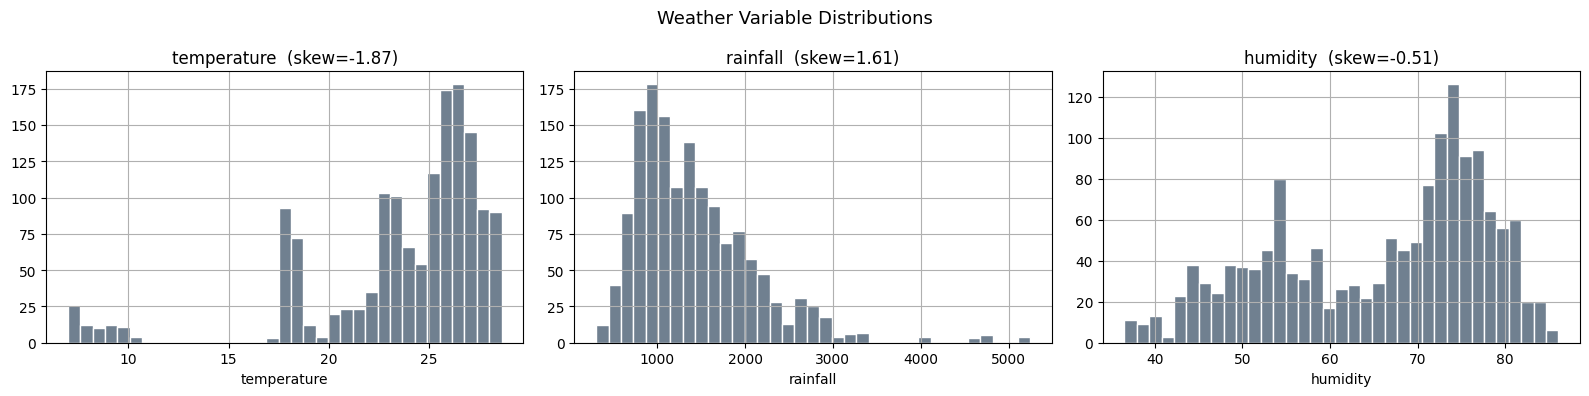

In [39]:
# Weather variable distributions + skewness check
weather_cols = ['temperature', 'rainfall', 'humidity']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(weather_cols):
    df[col].hist(bins=35, ax=axes[i], color='slategray', edgecolor='white')
    skew_val = df[col].skew()
    axes[i].set_title(f"{col}  (skew={skew_val:.2f})")
    axes[i].set_xlabel(col)

plt.suptitle("Weather Variable Distributions", fontsize=13)
plt.tight_layout()
plt.show()

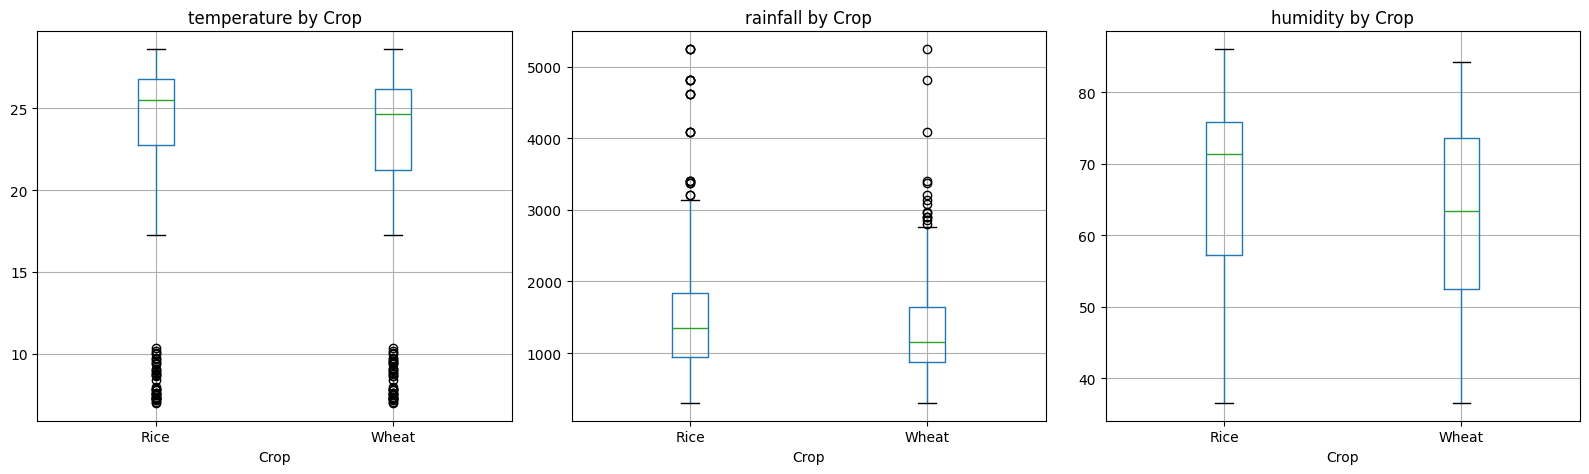

In [40]:
#Crop × weather interaction boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['temperature', 'rainfall', 'humidity']):
    df.boxplot(column=col, by='crop', ax=axes[i])
    axes[i].set_title(f"{col} by Crop")
    axes[i].set_xlabel("Crop")
    plt.sca(axes[i])
    plt.title(f"{col} by Crop")

plt.suptitle("")
plt.tight_layout()
plt.show()

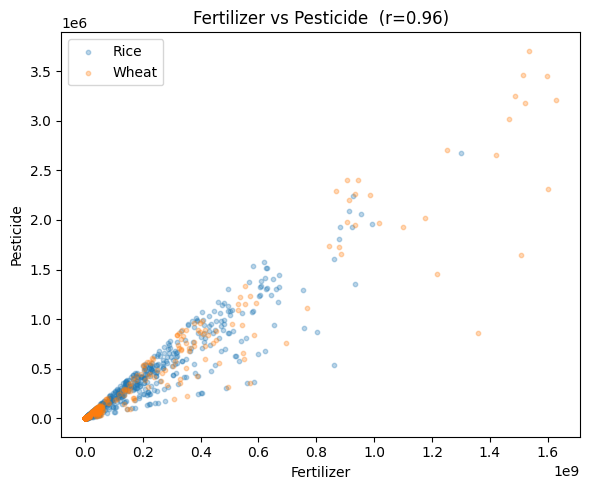

In [41]:
# Fertilizer vs Pesticide collinearity check
fig, ax = plt.subplots(figsize=(6, 5))
for crop, grp in df.groupby('crop'):
    ax.scatter(grp['fertilizer'], grp['pesticide'], alpha=0.3, s=10, label=crop)
corr_val = df['fertilizer'].corr(df['pesticide'])
ax.set_title(f"Fertilizer vs Pesticide  (r={corr_val:.2f})")
ax.set_xlabel("Fertilizer")
ax.set_ylabel("Pesticide")
ax.legend()
plt.tight_layout()
plt.show()

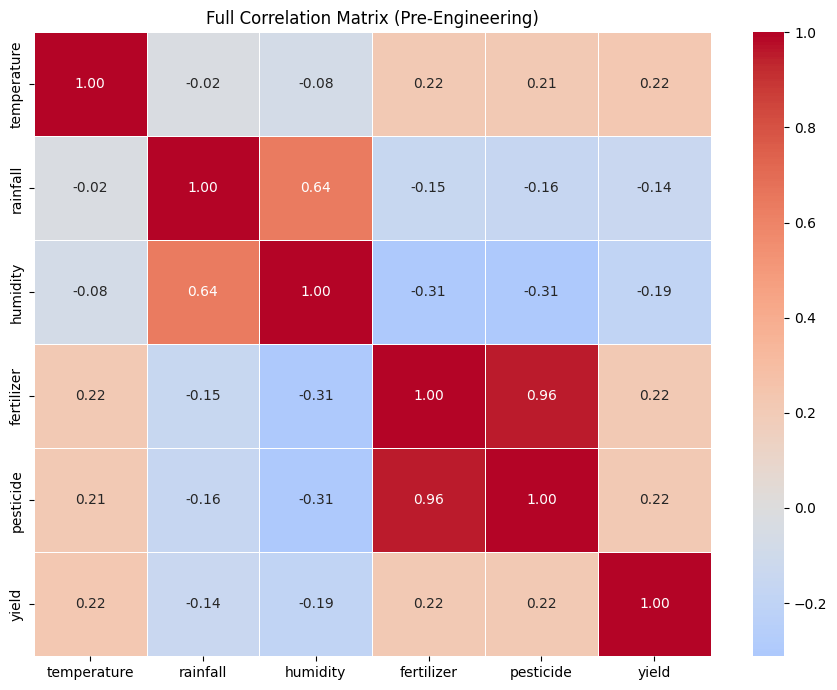

In [42]:
#Full correlation heatmap (pre-engineering baseline)
fig, ax = plt.subplots(figsize=(9, 7))
numeric_cols = ['temperature', 'rainfall', 'humidity', 'fertilizer', 'pesticide', 'yield']
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt=".2f", cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title("Full Correlation Matrix (Pre-Engineering)")
plt.tight_layout()
plt.show()

In [43]:
# MULTICOLLINEARITY FIX
df['agri_input'] = df['fertilizer'] + df['pesticide']
df.drop(columns=['fertilizer', 'pesticide'], inplace=True)

In [44]:
# OUTLIER CLIPPING
df['agri_input'] = df['agri_input'].clip(
    df['agri_input'].quantile(0.01),
    df['agri_input'].quantile(0.99)
)


In [45]:
#FEATURE ENGINEERING
df['temp_squared'] = df['temperature'] ** 2
df['humidity_squared'] = df['humidity'] ** 2
df['rainfall_squared'] = df['rainfall'] ** 2

df['humidity_temp'] = df['humidity'] * df['temperature']
df['temp_rainfall'] = df['temperature'] * df['rainfall']

df['log_rainfall'] = np.log1p(df['rainfall'])
df['rainfall_per_temp'] = df['rainfall'] / (df['temperature'] + 1)

df['year_trend'] = df['year'] - df['year'].min()
df['year_squared'] = df['year_trend'] ** 2

df['agri_weather'] = df['agri_input'] * df['temperature']

In [46]:
#TARGET ENCODING
state_mean = df.groupby('state')['yield'].mean()
df['state_encoded'] = df['state'].map(state_mean)
df.drop(columns=['state'], inplace=True)

#ENCODE CROP
df = pd.get_dummies(df, columns=['crop'], drop_first=True)

In [47]:
# SPLIT
X = df.drop(['yield'], axis=1)
y = df['yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
# MODELS

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost (Final)
xgb = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


In [49]:
#EVALUATION
print("Linear R2:", r2_score(y_test, y_pred_lr))
print("RF R2:", r2_score(y_test, y_pred_rf))
print("XGB R2:", r2_score(y_test, y_pred_xgb))

print("\nXGB RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

Linear R2: 0.6053547985268222
RF R2: 0.8439443972990062
XGB R2: 0.8484735126342133

XGB RMSE: 0.3456677923058926


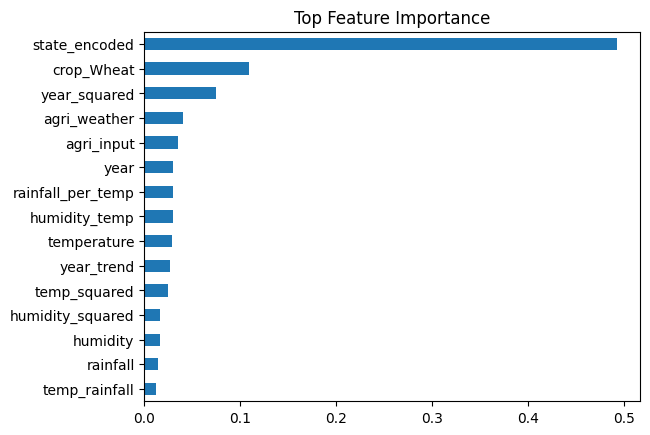

In [50]:
# FEATURE IMPORTANCE
importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance.sort_values().tail(15).plot(kind='barh')
plt.title("Top Feature Importance")
plt.show()


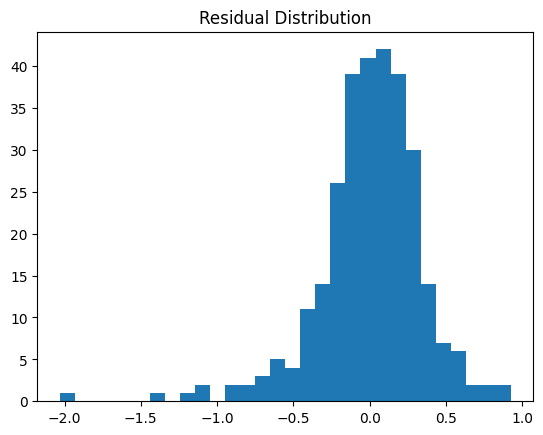

In [51]:
# RESIDUAL ANALYSIS
residuals = y_test - y_pred_xgb

plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()


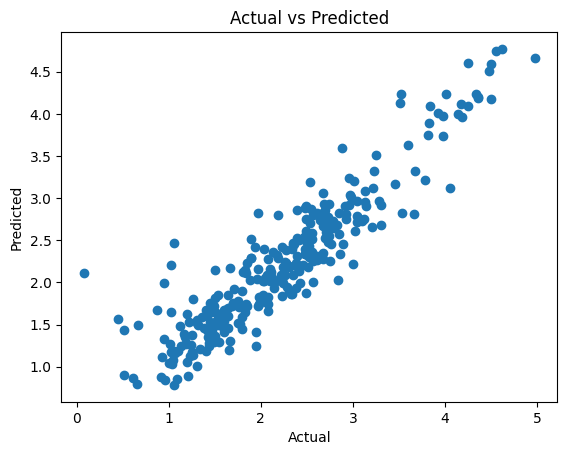

In [52]:
# PREDICTED VS ACTUAL
plt.figure()
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

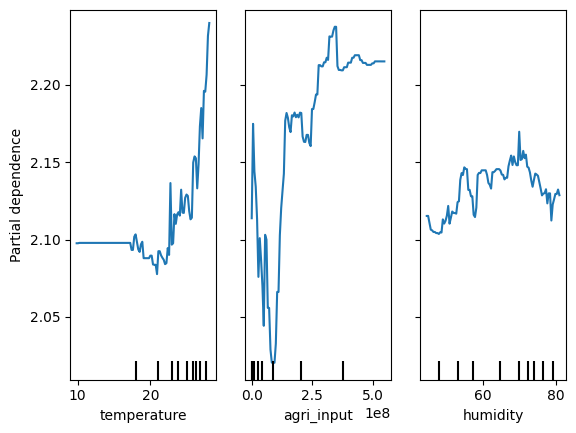

In [53]:
# PARTIAL DEPENDENCE
features = ['temperature', 'agri_input', 'humidity']
PartialDependenceDisplay.from_estimator(xgb, X_train, features)
plt.show()

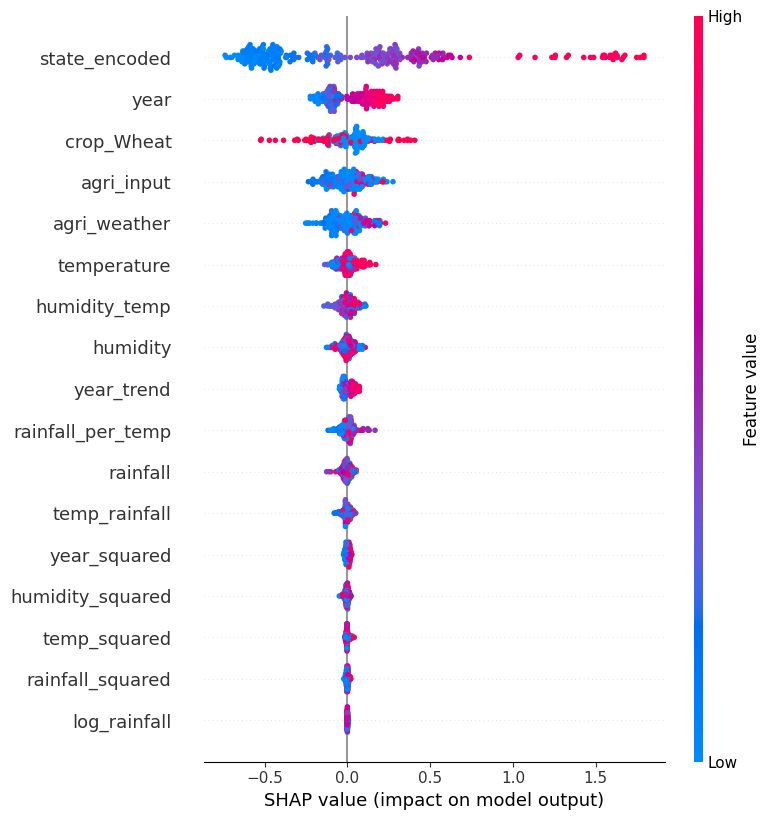

In [54]:
# SHAP VALUES
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

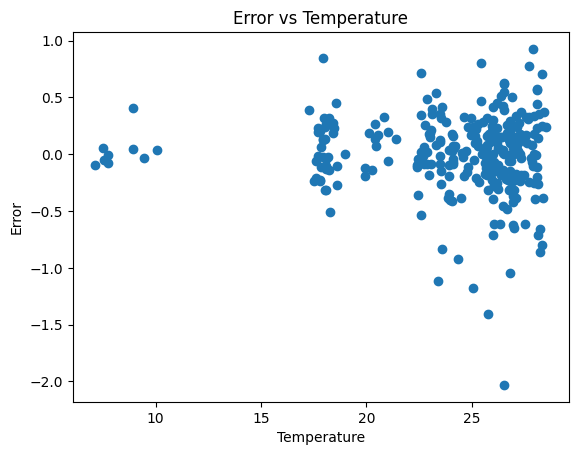

In [55]:
# ERROR VS FEATURE
plt.figure()
plt.scatter(X_test['temperature'], residuals)
plt.xlabel("Temperature")
plt.ylabel("Error")
plt.title("Error vs Temperature")
plt.show()

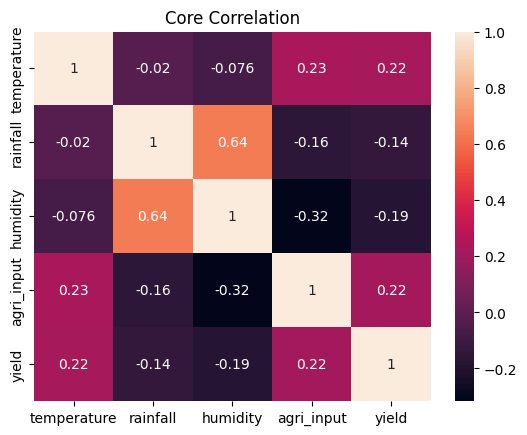

In [ ]:
# CORRELATION HEATMAP
cols = ['temperature', 'rainfall', 'humidity', 'agri_input', 'yield']
sns.heatmap(df[cols].corr(), annot=True)
plt.title("Core Correlation")
plt.show()